In [16]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical 

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns





In [ ]:


# %%
val_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)



# %%
test_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)



Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


In [ ]:
model_loaded = load_model('vgg16_finetuned_16072026_v3.keras')
#model_loaded.summary()

In [20]:

# jeu de test
test_pred = model_loaded.predict(test_ds)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)



66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 777ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 771ms/step


In [5]:
from collections import Counter

print(f"nombre de classes dans y_true_test_class  + {Counter(y_true_test_class)}")
print(f"nombre de classes dans test_pred_class  + {Counter(test_pred_class)}")


print(f"nombre de classes dans y_true_val_class  + {Counter(y_true_val_class)}")
print(f"nombre de classes dans val_pred_class  + {Counter(val_pred_class)}")


nombre de classes dans y_true_test_class  + Counter({np.int32(2): 1014, np.int32(1): 599, np.int32(0): 337, np.int32(3): 134})
nombre de classes dans test_pred_class  + Counter({np.int64(0): 1382, np.int64(2): 702})
nombre de classes dans y_true_val_class  + Counter({np.int32(2): 1013, np.int32(1): 598, np.int32(0): 338, np.int32(3): 134})
nombre de classes dans val_pred_class  + Counter({np.int64(0): 1382, np.int64(2): 701})


              precision    recall  f1-score   support

           0       0.15      0.65      0.24       337
           1       0.00      0.00      0.00       599
           2       0.45      0.24      0.32      1014
           3       0.19      0.09      0.12       134

    accuracy                           0.23      2084
   macro avg       0.20      0.24      0.17      2084
weighted avg       0.26      0.23      0.20      2084



/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

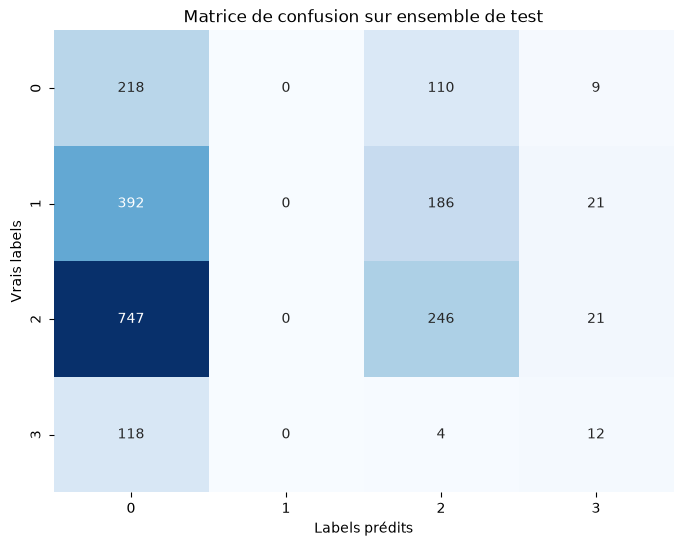

In [15]:
# Pour avoir le nom des classes (des poissons)
class_names = test_ds.class_names

print(metrics.classification_report(y_true_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


              precision    recall  f1-score   support

           0       0.18      0.06      0.09       338
           1       0.00      0.00      0.00       598
           2       0.49      0.96      0.65      1013
           3       0.00      0.00      0.00       134

    accuracy                           0.48      2083
   macro avg       0.17      0.26      0.19      2083
weighted avg       0.27      0.48      0.33      2083



/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/cyril/.conda/envs/projetLioraTensorFlow/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

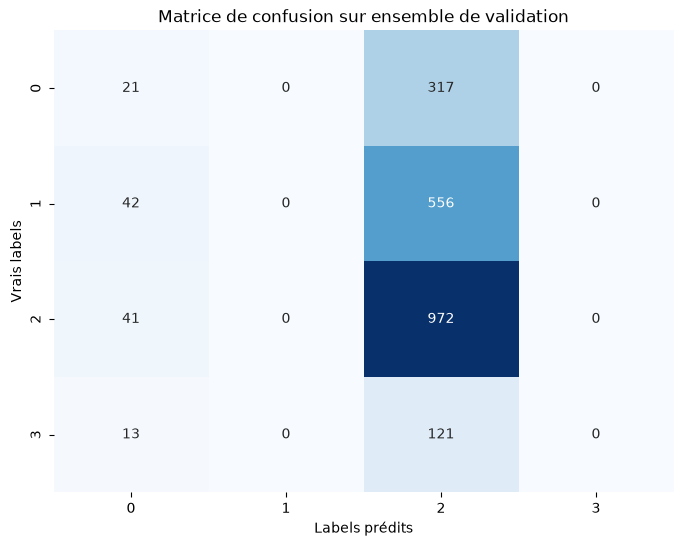

In [21]:
print(metrics.classification_report(y_true_val_class, val_pred_class))


# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_val_class, val_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de validation")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [8]:
import tensorflow as tf

def grad_cam(image, model, layer_name):
    # Récupérer la couche convolutive
    layer = model.get_layer(layer_name)
    
    # Créer un modèle qui génère les sorties de la couche convolutive et les prédictions
    grad_model = Model(inputs=model.input, outputs=[layer.output, model.output])

    # Ajout d'une dimension de batch
    image = tf.expand_dims(image, axis=0)

    # Calcul des gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        predicted_class = tf.argmax(predictions[0])  # Classe prédite
        loss = predictions[:, predicted_class]  # Perte pour la classe prédite

    # Gradients des scores par rapport aux sorties de la couche convolutive
    grads = tape.gradient(loss, conv_outputs)

    # Moyenne pondérée des gradients pour chaque canal
    pooled_grads = tf.reduce_mean(grads, axis=(0))

    # Pondération des activations par les gradients calculés
    conv_outputs = conv_outputs[0]  # Supprimer la dimension batch
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalisation de la carte de chaleur
    heatmap = tf.maximum(heatmap, 0)  # Se concentrer uniquement sur les valeurs positives
    heatmap /= tf.math.reduce_max(heatmap)  # Normaliser entre 0 et 1
    heatmap = heatmap.numpy()  # Convertir en tableau numpy pour la visualisation

   # Redimensionner la carte de chaleur pour correspondre à la taille de l'image d'origine
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[1], image.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1) # supprimer la dimension de taille 1 à la fin du tableau heatmap_resized

    # Colorier la carte de chaleur avec une palette (par exemple, "jet")
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :1] # Récupérer les canaux R, G, B 

    superimposed_image = heatmap_colored * 0.7 + image[0].numpy() / 255.0

    return np.clip(superimposed_image, 0, 1), predicted_class



In [9]:
def show_grad_cam_cnn(images, model):
    number_of_images = images.shape[0]
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    plt.figure(figsize=(16,16))

    for j, layer in enumerate(conv_layers):

        for i in range(number_of_images):

            subplot_index = i + 1 + j * number_of_images
            plt.subplot(len(conv_layers), number_of_images, subplot_index)

            # Obtenir l'image avec la carte de chaleur superposée
            grad_cam_image, predicted_class = grad_cam(images[i], model, layer)
            
            # Afficher l'image avec Grad-CAM
            plt.title(f'Grad-CAM {layer}')
            plt.imshow(grad_cam_image)
            plt.axis("off")

    plt.show()



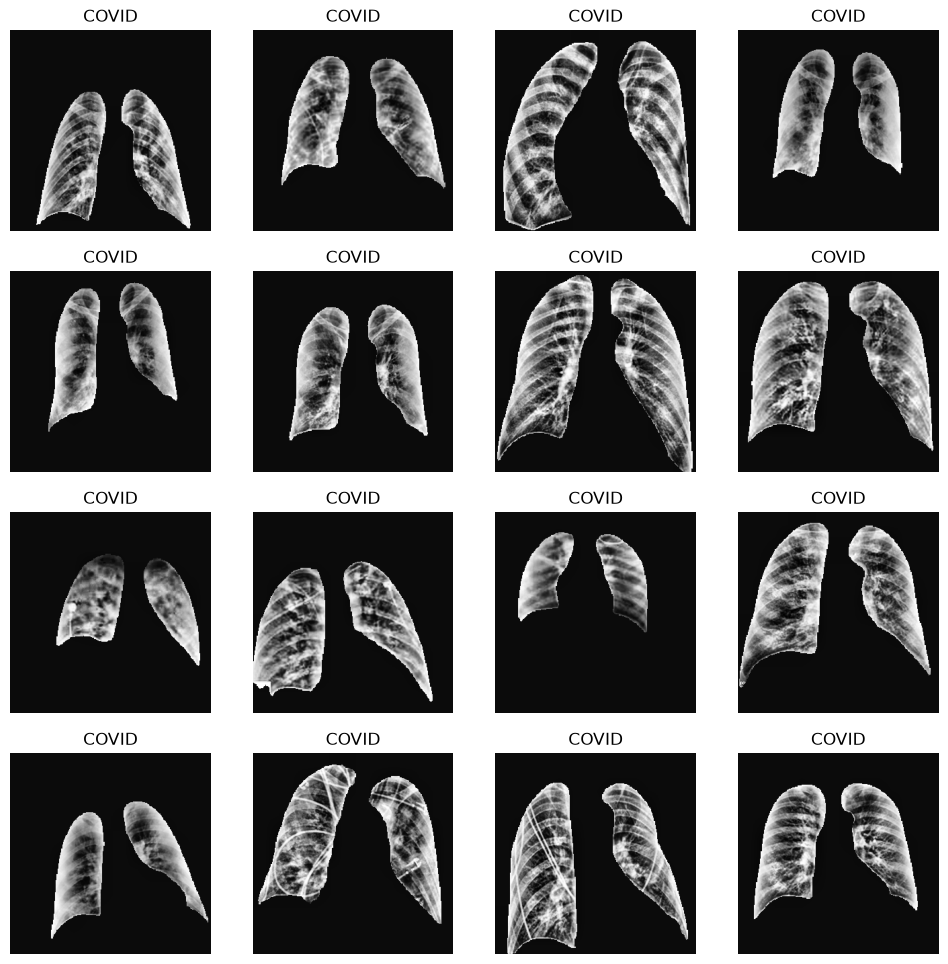

In [10]:

# Pour avoir le nom des classes (des poissons)
class_names = val_ds.class_names

# Définir le nombre d'images à afficher
number_of_images = 16

# Créer une figure pour l'affichage
plt.figure(figsize=(12,12))

# Obtenir un batch d'images depuis train_ds
for images, labels in val_ds.take(2): 
    # Afficher les images du batch
    for i in range(number_of_images):
        ax = plt.subplot(4, 4, i + 1) 
        plt.imshow(images[i].numpy().astype("uint8")) 
        plt.axis("off") 
        plt.title(f"{class_names[labels[i]]}")
        #plt.title(f"{labels[i]}")

# Afficher les images
plt.show()



